In [666]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2 
from pathlib import Path



In [667]:
#abrindo a imagem
imagem = Image.open('../imagens/originais/queimadas/queimada4.jpg')
imagem.show()

In [668]:
#largura e altura da imagem (pixel lXa)
tamanho = imagem.size
print(tamanho)

(678, 452)


In [669]:
#modo da imagem (RGB)
modo = imagem.mode
print(modo)

RGB


In [670]:
#descobrindo as cores de um pixel especifico para comparar area verde com queimadas 
pixel = imagem.getpixel((0,0))
print(pixel)

pixel2 = imagem.getpixel((100, 100))
print('Pixel área verde',pixel2)

pixel_queimada = imagem.getpixel((600, 200))
print('Pixel área queimada',pixel_queimada)

(15, 13, 14)
Pixel área verde (48, 42, 42)
Pixel área queimada (10, 9, 14)


In [671]:
#transformar todos os pixels em matrizes com valores RGB
imagem_array = np.array(imagem)
print(imagem_array.shape) #formato da matriz (a,l,RGB)

(452, 678, 3)


In [672]:
#separando canal de cores 
vermelho = imagem_array[:,:,0]
verde = imagem_array[:,:,1]
azul = imagem_array[:,:,2]
print(vermelho.shape, verde.shape,azul.shape)

(452, 678) (452, 678) (452, 678)


Deixando a imagem em tons cinzas para converter de 3 valoores (RGB) apenas para 1 

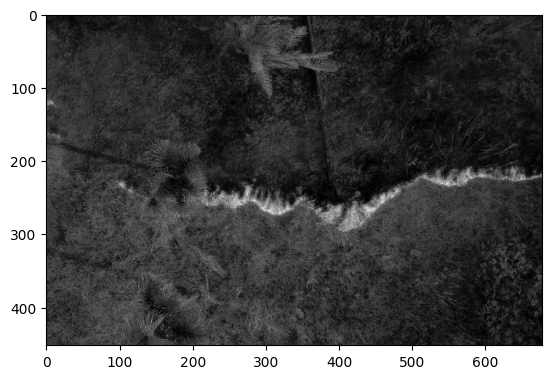

In [673]:
#isolando o vermelho
plt.imshow(vermelho, cmap='gray') #prepara a img 
plt.show() #mostra a img 

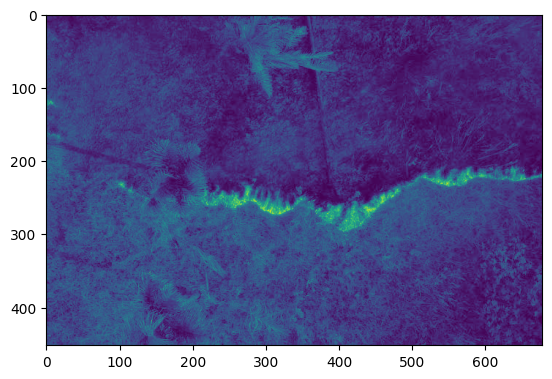

In [674]:
plt.imshow(vermelho) #prepara a img 
plt.show() #mostra a img 

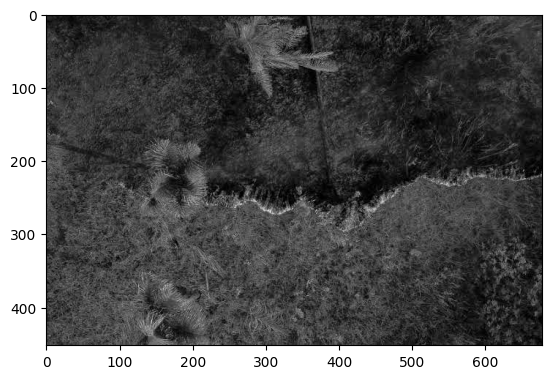

In [675]:
#isolando o verde
plt.imshow(verde, cmap='gray') #prepara a img 
plt.show() #mostra a img 

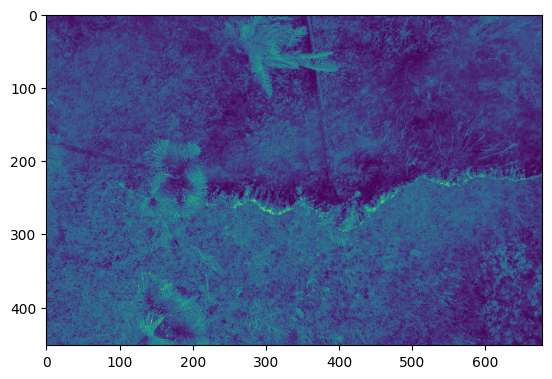

In [676]:
plt.imshow(verde) #prepara a img 
plt.show() #mostra a img 

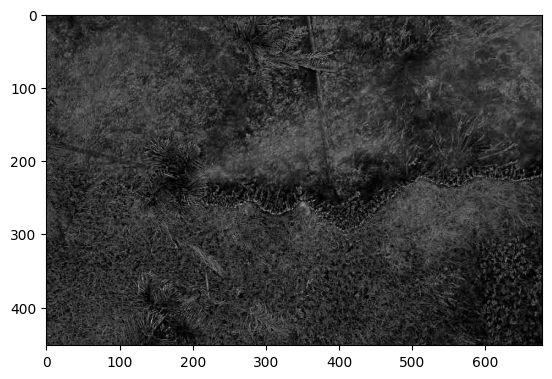

In [677]:
#isolando o azul
plt.imshow(azul, cmap='gray') #prepara a img 
plt.show() #mostra a img 

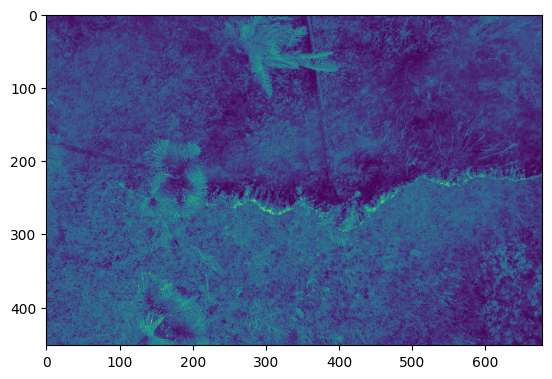

In [678]:
plt.imshow(verde) #prepara a img 
plt.show() #mostra a img 

L


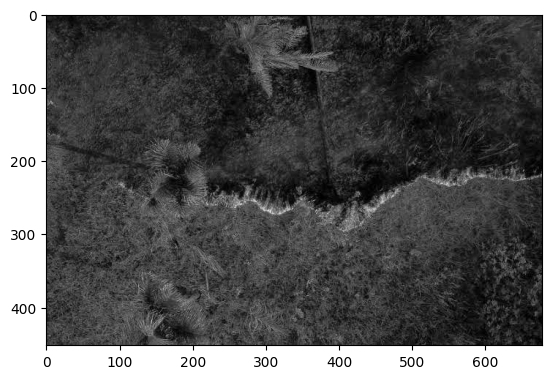

In [679]:
imagem_cinza = imagem.convert('L') # L pois vamos trabalhar com a luminosidade
print(imagem_cinza.mode)
imagem_cinza.size
plt.imshow(imagem_cinza, cmap='gray')
plt.show()

In [680]:
imagem_cinza_array = np.array(imagem_cinza)
print(imagem_cinza_array.shape) #formato da matriz (a,l) #confirmamos que não tem mais RGB esta baseando na luminosidade

(452, 678)


In [681]:
luminosidade_minima = imagem_cinza_array.min()
print(luminosidade_minima)

0


In [682]:
luminosidade_maxima = imagem_cinza_array.max()
print(luminosidade_maxima)

199


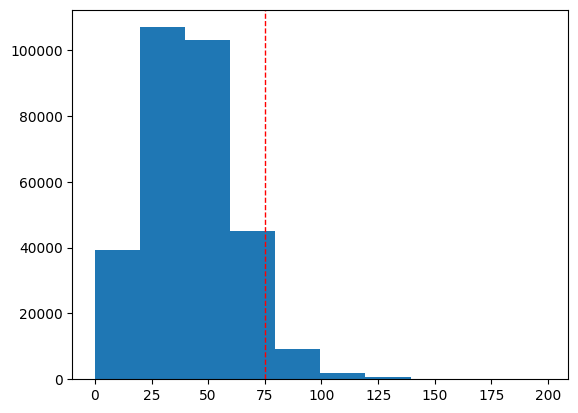

In [683]:
#criar um historiograma para analisar a distribuição dos valores da luminisidade e decidir a altura da mascara 
plt.hist(imagem_cinza_array.flatten())  #transformando a matriz em uma sequencia de valores
limite = 75 #iremos iniciar usando pixels a baixo de 50 como escuros para areas queimadas 
plt.axvline(limite, color='red', linestyle='--', linewidth=1)
plt.show()

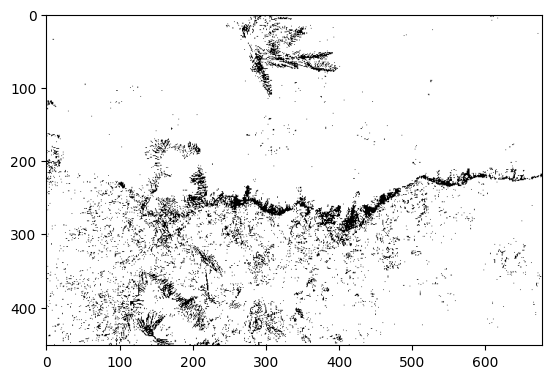

In [684]:
#compara os pixels que tem menos luminosidade que o limite(50)
mascara = imagem_cinza_array < limite
plt.imshow(mascara, cmap='gray')
plt.show()

In [685]:
#função para analisar RGB de pontos de pixels 
def analisar_pixel(x,y):
    pixel= imagem.getpixel((x,y))
    print(f'Cordenada: ({x}, {y})')
    print(f'RGB: {pixel}')

In [686]:
analisar_pixel(200,150)
analisar_pixel(600,200)
analisar_pixel(500,300)
analisar_pixel(100,100)

Cordenada: (200, 150)
RGB: (26, 24, 25)
Cordenada: (600, 200)
RGB: (10, 9, 14)
Cordenada: (500, 300)
RGB: (62, 59, 40)
Cordenada: (100, 100)
RGB: (48, 42, 42)


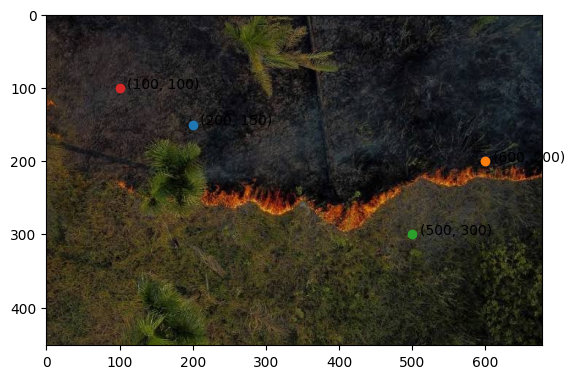

In [687]:
#confirmando onde esta cada ponto de pixel 
pontos = [(200, 150),
          (600, 200),
          (500, 300),
          (100, 100)
]

plt.imshow(imagem)

for x,y in pontos: 
    plt.scatter(x,y)
    plt.text(x + 10, y, f'({x}, {y})')
plt.show()



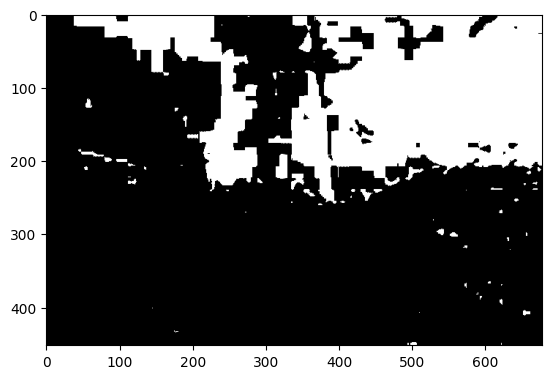

In [688]:
azul_maior_vermelho = azul > vermelho 
plt.imshow(azul_maior_vermelho, cmap='gray')
plt.show()

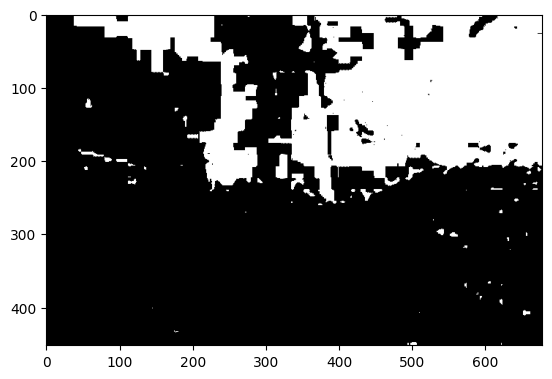

In [689]:
mascara_final = (imagem_cinza_array < limite) & (azul > vermelho)
plt.imshow(mascara_final, cmap='gray')
plt.show()

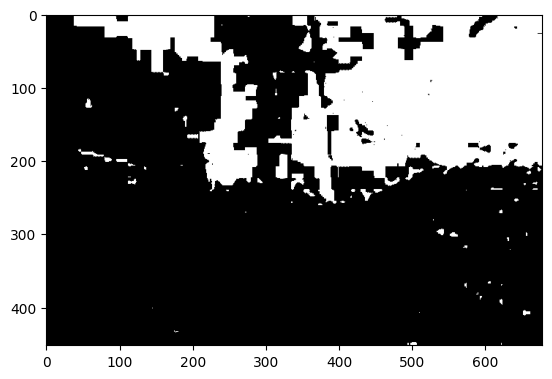

In [690]:
#conventendo a mascara_final de boleano para binario
conversao_mascara = mascara_final.astype(np.uint8) *255
plt.imshow(conversao_mascara, cmap='gray')
plt.show()

In [691]:
#limpeza de ruidos da img 
limp = np.ones((3,3), np.uint8)
print(limp)

[[1 1 1]
 [1 1 1]
 [1 1 1]]


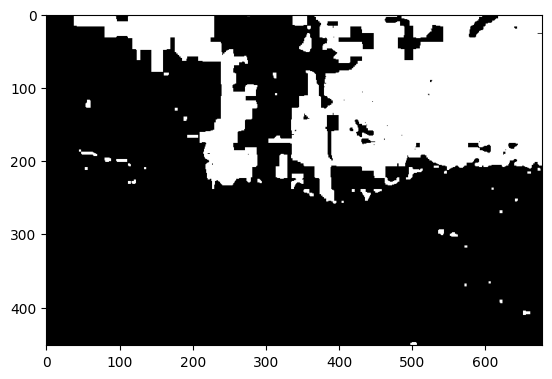

In [692]:
#limpeza de ruidos da img  
mascara_limpa = cv2.morphologyEx(conversao_mascara, cv2.MORPH_OPEN, limp) #operações morfológicas
plt.imshow(mascara_limpa, cmap='gray')
plt.show()

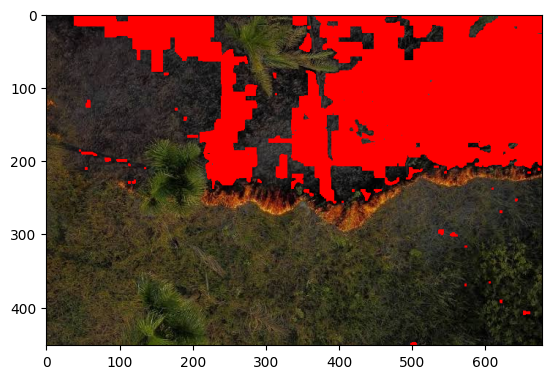

In [693]:
#deixando a area queimada em vermelho
img_resultado = imagem.copy()
resultado_array = np.array(img_resultado)
resultado_array[mascara_limpa > 0] = [255,0,0]
plt.imshow(resultado_array)
plt.show()

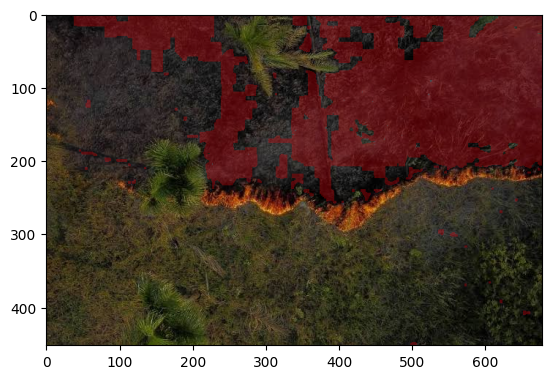

In [694]:
original = np.array(imagem)
sobrepossicao = original.copy()
sobrepossicao[mascara_limpa > 0] = [255,0,0]
resultado = cv2.addWeighted(original, 0.7, sobrepossicao, 0.3, 0)
plt.imshow(resultado)
plt.show()

In [695]:
#testes de luminosidade em pixels 
print(imagem_cinza_array[150,200])
print(imagem_cinza_array[200,600])
print(imagem_cinza_array[300,500])
print(imagem_cinza_array[100,100])

25
10
58
44


In [696]:
pasta_img = Path('../imagens/originais/queimadas')
pasta_resultado = Path('../imagens/originais/sem queimadas')
#cria a pasta se ela não existir

#procura as imagens 

imagens = list(pasta_img.glob("*.jpg"))
imagens += list(pasta_img.glob("*.jpeg"))
imagens += list(pasta_img.glob("*.png"))

print('Imagens encontradas!', len(imagens))

Imagens encontradas! 5


In [697]:
#Índice de Excesso de Verde
exg = 2 * verde - vermelho - azul
print(exg.shape)
print(exg.min())
print(exg.max())

(452, 678)
0
255


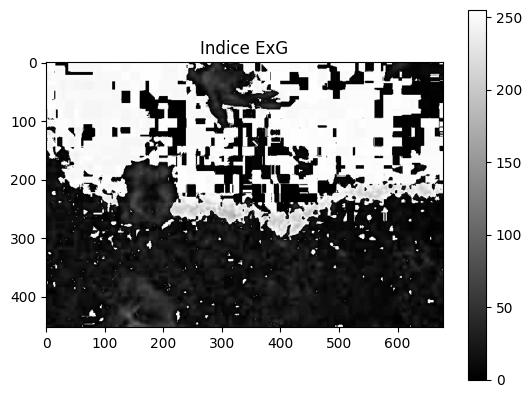

In [698]:
#valores maiores tem mais verde
plt.imshow(exg, cmap='gray')
plt.title('Indice ExG')
plt.colorbar() #mostrando escala de valores ao lado 
plt.show()

In [699]:
#transformando areas em binario 
limite, mascara = cv2.threshold(exg,0,255,cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU) #threshold procura automaticamente um ponto de separação, OTSU calcula o limite sozinho
print('Limite encontrado', limite)

Limite encontrado 108.0


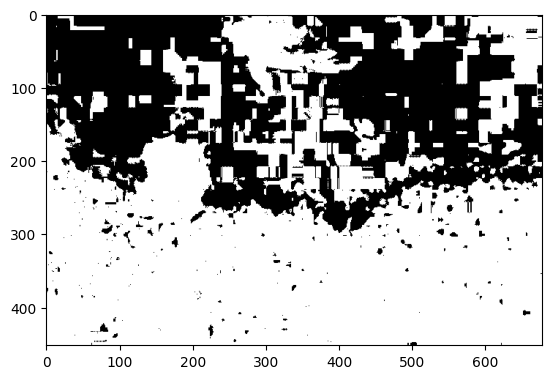

In [700]:
plt.imshow(mascara, cmap='gray')
plt.show()